# Rewind — Exploratory Data Analysis

This notebook is the analytical foundation for **Rewind**, a Spotify listening-data analytics tool. It ingests a user's [Extended Streaming History](https://support.spotify.com/account/privacy-settings/) export, cleans and reshapes the data, then derives every metric the Rewind dashboard surfaces: total listening time, top artist / track / album, the GitHub-style activity heatmap, most-hated artist and track, active-day count, and unique-song count.

All discoveries here feed directly into the FastAPI backend endpoints defined in `backend/main.py` and the frontend cards rendered in `overview.html`.

---

## 1 · Environment Setup

Import the core analysis stack: **NumPy** for numeric operations, **Pandas** for tabular data, **Matplotlib** and **Seaborn** for visualization, and `pathlib` for portable file paths.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pathlib import Path

## 2 · Project Root Resolution

Since this notebook lives inside `notebooks/`, we resolve the project root one level up. All subsequent data paths are relative to `base`, keeping the notebook runnable regardless of the working directory.

In [3]:
base = Path.cwd().parent

## 3 · Data Ingestion

Spotify delivers the Extended Streaming History as one or more JSON files, each containing an array of stream-event objects. Here we load **both export files** and concatenate them into a single DataFrame — the canonical dataset for every analysis that follows.

> **Note:** The schema of these JSON files is documented in `SCHEMA.md`. Each record represents one playback event and carries ~20 fields covering timestamp, platform, duration, geographic metadata, track/artist/album identifiers, and behavioral flags (shuffle, skip, offline, incognito).

In [4]:
part1 = pd.read_json(base / "data" / "Streaming_History_Audio_2025_1.json")
part2 = pd.read_json(base / "data" / "Streaming_History_Audio_2022-2025_0.json")
df = pd.concat([part1, part2], ignore_index=True)

## 4 · Initial Cleanup

Two cleanup steps run before any analysis:

1. **Drop empty columns** — Spotify's export sometimes includes columns that are entirely `NaN` (e.g., podcast-specific fields for a music-only listener). These add noise with zero analytical value.
2. **Drop `ip_addr`** — Personal network data carries real privacy risk and has no analytical use case in Rewind. This matches the backend's ingestion policy (see `SCHEMA.md` and `BACKEND.md`).

In [5]:
df.dropna(axis=1, how='all', inplace=True)
df.drop(columns=['ip_addr'], inplace=True)

## 5 · Type Casting

Raw JSON import leaves every column as a generic `object` dtype. Here we apply the correct types:

| Column | Target Type | Rationale |
|--------|-------------|----------|
| `ts` | `datetime64` | Enables date arithmetic, resampling, and heatmap bucketing |
| `platform`, `conn_country`, `reason_start`, `reason_end` | `category` | Low-cardinality strings — category dtype drastically reduces memory and speeds groupby |
| `shuffle`, `skipped`, `offline`, `incognito_mode` | `boolean` | Proper boolean semantics, nullable |

Correct dtypes are not cosmetic — they prevent silent bugs in aggregations (e.g., summing a string-typed boolean) and cut memory usage by ~40%.

In [6]:
df['ts'] = pd.to_datetime(df['ts'])
df['platform'] = df['platform'].astype('category')
df['conn_country'] = df['conn_country'].astype('category')
df['reason_start'] = df['reason_start'].astype('category')
df['reason_end'] = df['reason_end'].astype('category')
df['shuffle'] = df['shuffle'].astype('boolean')
df['skipped'] = df['skipped'].astype('boolean')
df['offline'] = df['offline'].astype('boolean')
df['incognito_mode'] = df['incognito_mode'].astype('boolean')

## 6 · Unit Conversion — Milliseconds → Minutes

Spotify records playback duration in **milliseconds** (`ms_played`). For human-readable metrics — total listening time, per-artist minutes — we convert to **minutes** in-place. The Rewind dashboard's "Total Listening Time" card consumes this value directly.

In [7]:
df['ms_played'] = df['ms_played'] / 1000 / 60  # Convert to minutes

## 7 · Schema Inspection

A quick `df.info()` sanity check to verify:
- All 17,648 stream events loaded successfully
- Dtypes are as expected after casting
- Non-null counts flag any remaining data-quality issues
- Memory footprint is reasonable (~1.7 MB for ~18k rows)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17648 entries, 0 to 17647
Data columns (total 19 columns):
 #   Column                             Non-Null Count  Dtype              
---  ------                             --------------  -----              
 0   ts                                 17648 non-null  datetime64[ns, UTC]
 1   platform                           17648 non-null  category           
 2   ms_played                          17648 non-null  float64            
 3   conn_country                       17648 non-null  category           
 4   master_metadata_track_name         17646 non-null  object             
 5   master_metadata_album_artist_name  17646 non-null  object             
 6   master_metadata_album_album_name   17646 non-null  object             
 7   spotify_track_uri                  17646 non-null  object             
 8   audiobook_title                    2 non-null      object             
 9   audiobook_uri                      2 non-null     

## 8 · Temporal Distribution of Listening Activity

A 100-bin histogram of the `ts` (timestamp) column reveals **when** listening happens over the life of the dataset. This visualization directly informs the Rewind dashboard's **GitHub-style listening activity heatmap** — it answers the question: *"Are there sustained periods of silence, or is listening fairly continuous?"*

Gaps in the distribution may indicate data export boundaries, device changes, or genuine listening breaks.

<Axes: >

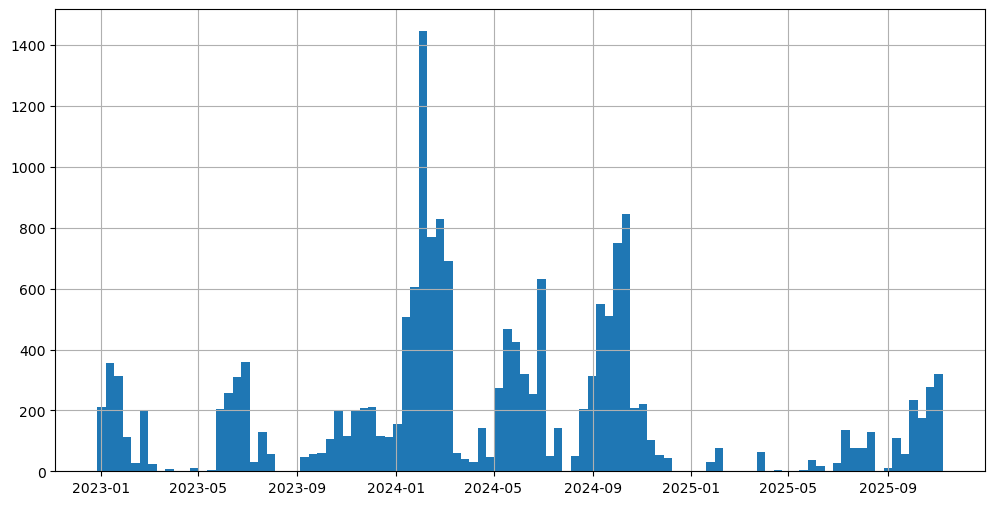

In [9]:
df['ts'].hist(bins=100, figsize=(12, 6))

## 9 · Top 10 Artists by Stream Count

A straightforward bar chart ranking artists by raw play count. This mirrors the logic behind Rewind's **Top Artist** metric card (`/api/metrics/top-artist`) — the artist with the most stream events wins. Stream count (rather than total minutes) is used here because it better reflects intentional engagement: a user who starts a track is making a choice, regardless of whether they listen to the full duration.

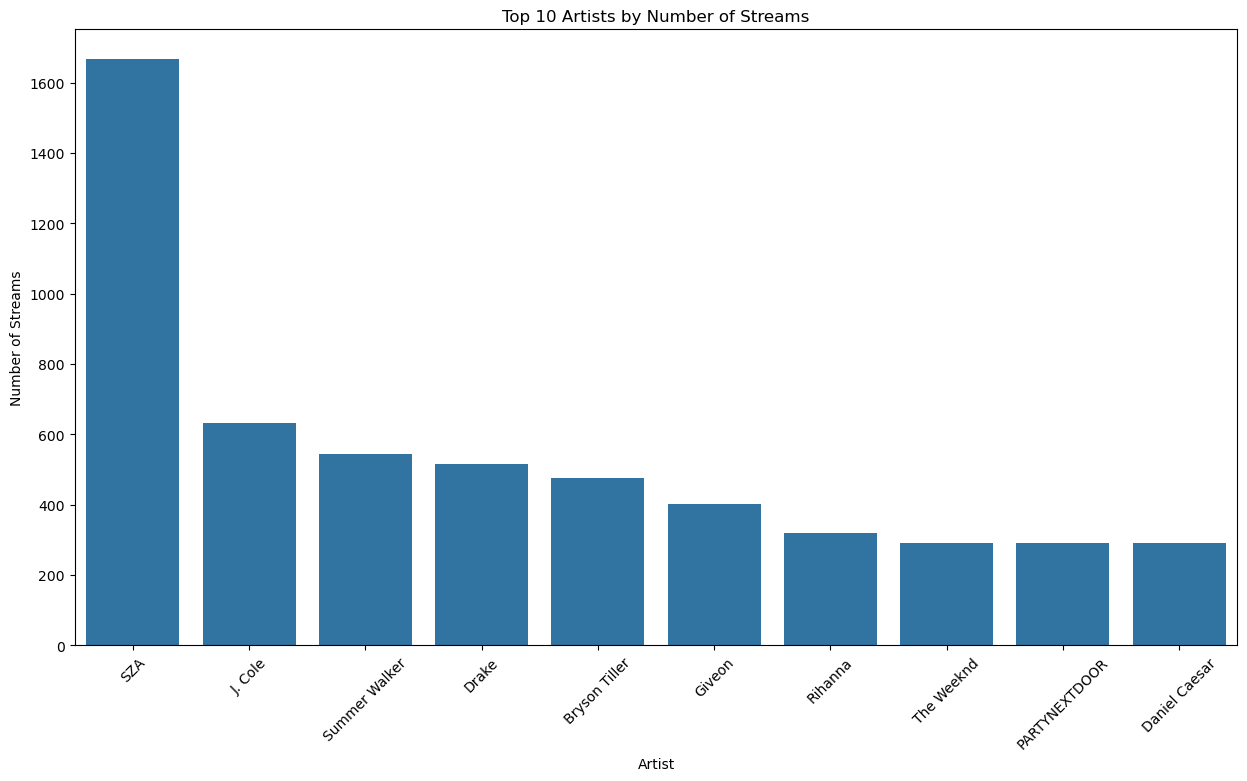

In [10]:
tmp = df['master_metadata_album_artist_name'].value_counts()
plt.figure(figsize=(15, 8))
sns.barplot(x=tmp.index[:10], y=tmp.values[:10])
plt.xticks(rotation=45)
plt.title('Top 10 Artists by Number of Streams')
plt.xlabel('Artist')
plt.ylabel('Number of Streams')
# plt.tight_layout()
plt.show()

## 10 · Full Dataset Preview

Display the complete DataFrame to visually spot-check field values, confirm dtypes are rendering correctly, and inspect edge cases (e.g., audiobook rows, very short `ms_played` values from skips, `reason_end` values like `unexpected-exit-while-paused`). This cell is a diagnostic checkpoint — not used in production.

In [11]:
df

,ts,platform,ms_played,conn_country,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,spotify_track_uri,audiobook_title,audiobook_uri,audiobook_chapter_uri,audiobook_chapter_title,reason_start,reason_end,shuffle,skipped,offline,offline_timestamp,incognito_mode
0,2025-07-14 15:03:40+00:00,windows,2.387100,ET,Playing Games (with Bryson Tiller) - Extended ...,Summer Walker,Over It,spotify:track:2xyx0o4xNOLLjBSbOOdcbA,NaN,NaN,NaN,NaN,playbtn,trackdone,True,False,False,1752505275,False
1,2025-07-14 15:05:30+00:00,windows,1.823550,ET,BP,Summer Walker,Last Day Of Summer,spotify:track:7B1c8GzIeRVfuU7pqgmBaR,NaN,NaN,NaN,NaN,trackdone,trackdone,True,False,False,1752505420,False
2,2025-07-14 15:09:20+00:00,windows,3.387333,ET,CPR,Summer Walker,Last Day Of Summer,spotify:track:5Tp4UJvnsF4Zd05k0zXUte,NaN,NaN,NaN,NaN,trackdone,trackdone,True,False,False,1752505556,False
3,2025-07-14 15:12:06+00:00,windows,2.750000,ET,Spend It,Summer Walker,Spend It,spotify:track:290eKCMBc9f9CcSLFuQrim,NaN,NaN,NaN,NaN,trackdone,trackdone,True,False,False,1752505760,False
4,2025-07-14 15:15:06+00:00,windows,2.999550,ET,I'll Kill You (feat. Jhené Aiko),Summer Walker,Over It,spotify:track:7EkiMl81fUHVwpItgtzI4r,NaN,NaN,NaN,NaN,trackdone,trackdone,True,False,False,1752505926,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17643,2025-07-13 03:17:50+00:00,android,3.424300,ET,Calling My Phone,Lil Tjay,Destined 2 Win,spotify:track:3J8EOeKLTLXORtWPpOU5bE,None,None,None,None,trackdone,trackdone,True,False,False,1752376252,False
17644,2025-07-13 04:17:14+00:00,windows,4.047050,ET,2AM,SZA,Ctrl (Deluxe),spotify:track:3vZGtceCbJVh5aDT4XhE0p,None,None,None,None,clickrow,trackdone,False,False,False,1752379988,False
17645,2025-07-13 04:18:49+00:00,windows,1.162133,ET,Miles,SZA,Ctrl (Deluxe),spotify:track:4pHy0gmjfpD0Fgond5c4Ta,None,None,None,None,trackdone,trackdone,False,False,False,1752380259,False
17646,2025-07-13 04:20:13+00:00,windows,1.400000,ET,Percolator,SZA,Ctrl (Deluxe),spotify:track:4UJuFZ4btsiGqMyFHBRPbo,None,None,None,None,trackdone,trackdone,False,False,False,1752380328,False


---

## 11 · Skip-Rate Analysis — Artist Level

From here, the notebook shifts from descriptive summaries to **behavioral analytics**: identifying the user's *most-hated* artists and tracks. The Rewind dashboard surfaces a "Most Hated Artist" card — this section is its analytical backbone.

We group by artist and compute:
- `total_plays` — total stream events (denominator)
- `skips` — count of plays where `skipped == True` (numerator)
- `skip_rate` — proportion of streams the user skipped

Raw skip rate alone is misleading (an artist played once and skipped once has a 100% rate), so all downstream visualizations apply a minimum-play threshold to filter out low-sample noise.

In [12]:
artist_stats = df.groupby('master_metadata_album_artist_name').agg(
    total_plays=('ts', 'count'),
    skips=('skipped', 'sum')
)
artist_stats['skip_rate'] = artist_stats['skips'] / artist_stats['total_plays']


## 12 · Skip Rate vs. Total Plays — Artist Scatter Plot

This scatter plot maps every artist (with ≥ 30 plays) on two axes:
- **x-axis:** total play count — a proxy for familiarity
- **y-axis:** skip rate — a proxy for dislike

The **dashed gray line** marks the user's global average skip rate. Artists *above* the line are skipped more than average; artists *below* are listened to more patiently.

**Annotations:** The top-5 highest skip-rate artists are labeled in black; the top-4 most-played artists are labeled in red. The interesting quadrant is upper-right: artists the user plays frequently but also skips heavily — a love-hate signal.

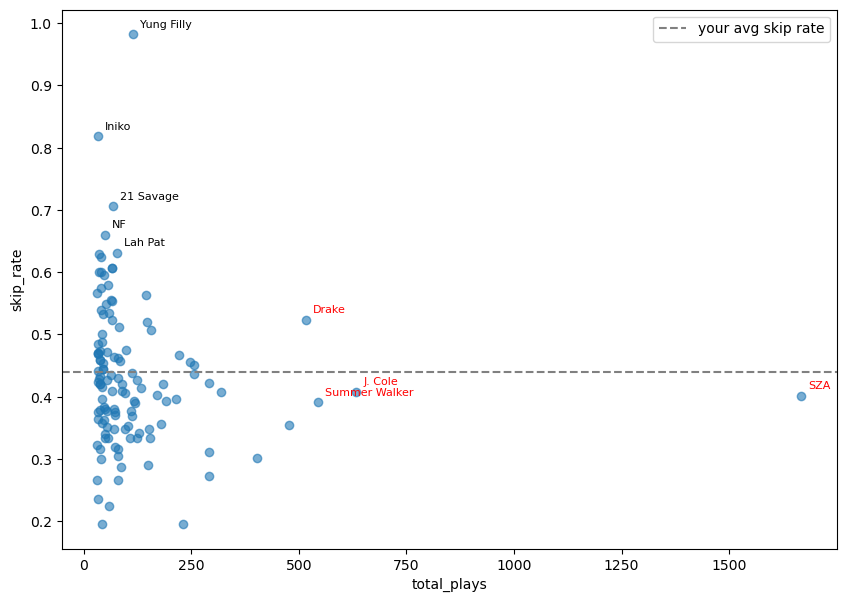

In [13]:
# only keep artists with a reasonable sample size, otherwise low-n noise dominates
filtered = artist_stats[artist_stats['total_plays'] >= 30].copy()

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(filtered['total_plays'], filtered['skip_rate'], alpha=0.6)

# label only the extremes so it's not cluttered
top_candidates = filtered.sort_values('skip_rate', ascending=False).head(5)
top_favorite = filtered.sort_values('total_plays', ascending=False).head(4)

for name, row in top_candidates.iterrows():
    ax.annotate(name, (row['total_plays'], row['skip_rate']), fontsize=8, xytext=(5,5), textcoords='offset points')
for name, row in top_favorite.iterrows():
    ax.annotate(name, (row['total_plays'], row['skip_rate']), fontsize=8, color='red', xytext=(5,5), textcoords='offset points')

ax.axhline(df['skipped'].mean(), color='gray', linestyle='--', label='your avg skip rate')
ax.set_xlabel('total_plays')
ax.set_ylabel('skip_rate')
ax.legend()
plt.show()

## 13 · Skip-Rate Analysis — Track Level

The same skip-rate computation applied at the **track** granularity. This powers the Rewind dashboard's "Most Hated Track" card.

Tracks with ≥ 10 plays are retained and sorted by descending skip rate. The higher threshold for artists (30) vs. tracks (10) reflects that individual tracks naturally accumulate fewer plays than artist-level totals.

In [14]:
track_stats = df.groupby('master_metadata_track_name').agg(
    total_plays=('ts', 'count'),
    skips=('skipped', 'sum')
)
track_stats['skip_rate'] = track_stats['skips'] / track_stats['total_plays']

# filter out artists you've barely played, otherwise n=1 100%-skip artists dominate
track_stats[track_stats['total_plays'] >= 10].sort_values('skip_rate', ascending=False)

,total_plays,skips,skip_rate
master_metadata_track_name,,,
Grey,115,113,0.982609
She Make It Clap,15,14,0.933333
Yosemite (Song For The Ahwahnechee),14,13,0.928571
Drip Too Hard (Lil Baby & Gunna),13,11,0.846154
Rich Baby Daddy (feat. Sexyy Red & SZA),31,26,0.83871
...,...,...,...
STRANGERS,12,1,0.083333
See You Again (feat. Kali Uchis),14,1,0.071429
I CAN TELL,12,0,0.0


## 14 · Skip Rate vs. Total Plays — Track Scatter Plot

An analogous scatter plot at the track level (threshold: ≥ 20 plays). The same visual language applies: the gray dashed line is the global skip rate, top-5 highest skip-rate tracks labeled in black, top-4 most-played in red.

This view often reveals individual tracks that the user's playlist or autoplay feeds them repeatedly — but that they almost always skip.

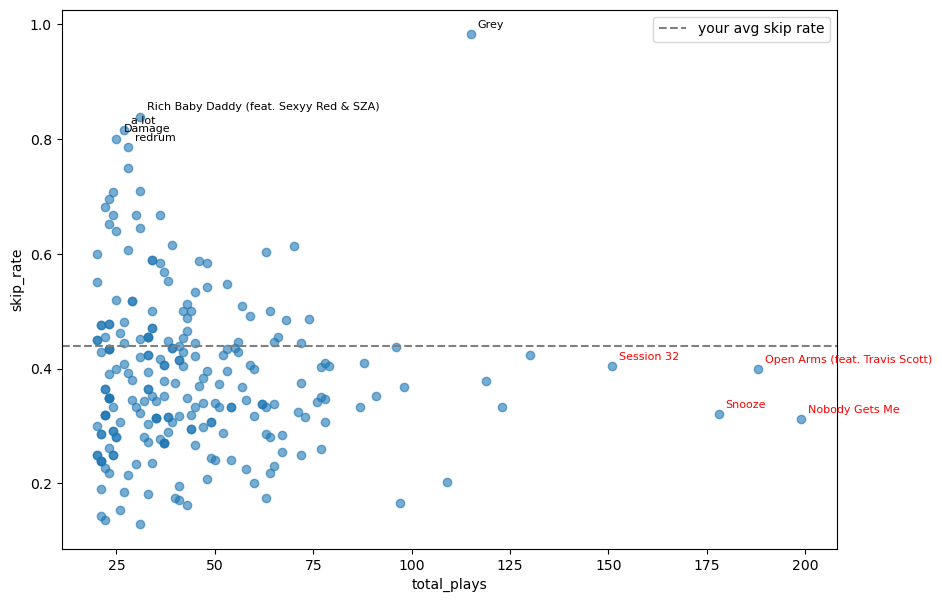

In [15]:
# only keep artists with a reasonable sample size, otherwise low-n noise dominates
filtered = track_stats[track_stats['total_plays'] >= 20].copy()

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(filtered['total_plays'], filtered['skip_rate'], alpha=0.6)

# label only the extremes so it's not cluttered
top_candidates = filtered.sort_values('skip_rate', ascending=False).head(5)
top_favorite = filtered.sort_values('total_plays', ascending=False).head(4)

for name, row in top_candidates.iterrows():
    ax.annotate(name, (row['total_plays'], row['skip_rate']), fontsize=8, xytext=(5,5), textcoords='offset points')
for name, row in top_favorite.iterrows():
    ax.annotate(name, (row['total_plays'], row['skip_rate']), fontsize=8, color='red', xytext=(5,5), textcoords='offset points')

ax.axhline(df['skipped'].mean(), color='gray', linestyle='--', label='your avg skip rate')
ax.set_xlabel('total_plays')
ax.set_ylabel('skip_rate')
ax.legend()
plt.show()

---

## 15 · Statistical Rigour — Binomial Test for Skip Surprise

Raw skip rates are noisy. Is an artist's 60% skip rate *meaningfully* higher than the user's global 35% rate, or just sampling noise from a handful of plays?

We use a **one-sided binomial test** (`scipy.stats.binomtest`) per artist:
- **H₀:** This artist's true skip probability equals the user's global skip rate
- **H₁:** This artist's true skip probability is *greater* (i.e., the user hates them more)

A small p-value means the observed skip count is unlikely under "normal" listening behavior. This transforms the naïve "sort by skip rate" approach into a statistically grounded ranking.

In [16]:
from scipy.stats import binomtest

global_skip_rate = df['skipped'].mean()  # your overall skip rate across everything

def skip_surprise(artist_name, p=global_skip_rate):
    skips = artist_stats.loc[artist_name, 'skips']
    plays = artist_stats.loc[artist_name, 'total_plays']
    result = binomtest(skips, plays, p, alternative='greater')
    return result.pvalue  # small = surprising, this artist isn't "just average"

## 16 · Compute Skip-Surprise p-Values

Apply the binomial test to **every artist** in the dataset, storing the resulting p-value in a new `skip_surprise` column. Smaller values → stronger evidence that the artist is genuinely skipped at an above-average rate.

In [17]:
artist_stats['skip_surprise'] = artist_stats.index.map(skip_surprise)

## 17 · Volcano-Style Plot — Statistical Significance of Skip Behavior

Inspired by genomics volcano plots, this chart maps:
- **x-axis (log scale):** total plays — how familiar the artist is
- **y-axis:** `-log10(p-value)` — how *surprising* their skip rate is (higher = more extreme)

The **dashed gray line** marks the p = 0.05 significance threshold. Points above it (colored crimson) are artists whose elevated skip rate is **statistically significant** — not just random noise.

The top-5 most-surprising artists are labeled. These are the strongest candidates for the Rewind "Most Hated Artist" title.

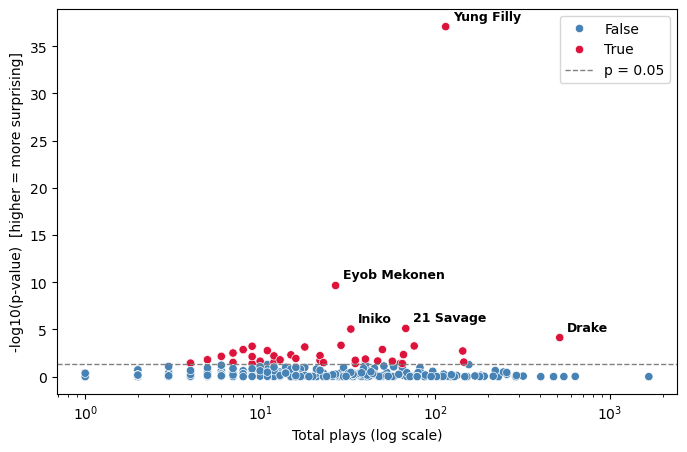

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# avoid log(0) for any p-values that underflowed to exactly 0
artist_stats['neg_log_p'] = -np.log10(artist_stats['skip_surprise'].clip(lower=1e-300))
artist_stats['significant'] = artist_stats['skip_surprise'] < 0.05

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(
    data=artist_stats, x='total_plays', y='neg_log_p',
    hue='significant', palette={True: 'crimson', False: 'steelblue'},
    ax=ax
)
top3 = artist_stats.nsmallest(5, 'skip_surprise')

for _, row in top3.iterrows():
    ax.annotate(
        row.name,  # swap this for whatever your artist name column is actually called
        xy=(row['total_plays'], row['neg_log_p']),
        xytext=(5, 5), textcoords='offset points',
        fontsize=9, fontweight='bold'
    )
ax.set_xscale('log')
ax.axhline(-np.log10(0.05), color='gray', linestyle='--', linewidth=1, label='p = 0.05')
ax.set_xlabel('Total plays (log scale)')
ax.set_ylabel('-log10(p-value)  [higher = more surprising]')
ax.legend()
plt.show()

## 18 · Wilson Confidence Intervals for Skip Rate

The binomial test tells us *if* an artist's skip rate is unusual, but not *how much*. **Wilson score intervals** (via `statsmodels.stats.proportion.proportion_confint`) provide a 95% confidence band around each artist's true skip probability.

Wilson intervals are preferred over naïve Wald intervals because they perform well even at small sample sizes and extreme proportions (near 0 or 1) — exactly the regime low-play artists occupy.

In [19]:
from statsmodels.stats.proportion import proportion_confint

artist_stats['low'], artist_stats['high'] = zip(*artist_stats.apply(
    lambda row: proportion_confint(count=row['skips'], nobs=row['total_plays'], alpha=0.05, method='wilson'),
    axis=1
))

## 19 · Ranking by Lower Confidence Bound — The "Most Hated" Leaderboard

The final visualization sorts artists by the **lower bound** of their Wilson 95% CI, not by raw skip rate. This is the key insight: ranking by the lower bound penalizes artists with few plays (wide intervals push the lower bound down) and rewards artists where we have strong evidence of a high skip rate.

- **Crimson dots:** observed skip rate
- **Gray whiskers:** 95% Wilson confidence interval
- **Blue dashed line:** user's global skip rate

Artists whose entire CI sits above the global line are the most robustly "hated". The top result feeds directly into Rewind's **Most Hated Artist** dashboard card.

> **Production note:** The backend endpoint for this metric will mirror this methodology — sorting by the Wilson lower bound with a minimum-play threshold — ensuring the dashboard card is grounded in statistical confidence, not sampling noise.

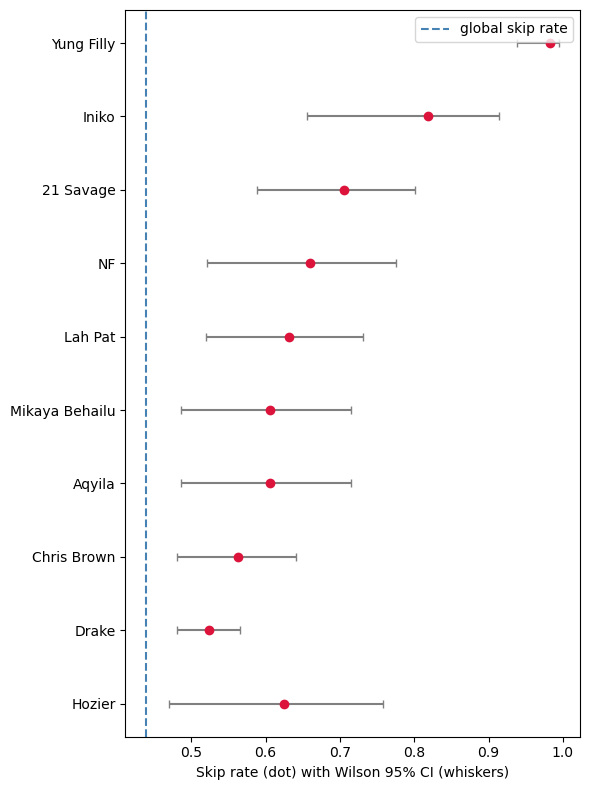

In [27]:
top_n = 10
artist_stats['raw_rate'] = artist_stats['skips'] / artist_stats['total_plays']
artist_stats = artist_stats[artist_stats['total_plays'] >= 20]  # filter out low-n artists

# sort by 'low', not raw_rate -- this IS the point of the whole exercise
top = artist_stats.nlargest(top_n, 'low').sort_values('low')

fig, ax = plt.subplots(figsize=(6, 8))
y_pos = range(len(top))

xerr_low = np.clip(top['raw_rate'] - top['low'], 0, None)
xerr_high = np.clip(top['high'] - top['raw_rate'], 0, None)

ax.errorbar(
    top['raw_rate'], y_pos,
    xerr=[xerr_low, xerr_high],
    fmt='o', color='crimson', ecolor='gray', capsize=3
)
ax.axvline(global_skip_rate, color='steelblue', linestyle='--', label='global skip rate')
ax.set_yticks(y_pos)
ax.set_yticklabels(top.index)
ax.set_xlabel('Skip rate (dot) with Wilson 95% CI (whiskers)')
ax.legend()
plt.tight_layout()
plt.show()

In [3]:
import duckdb

# Connect to an in-memory DuckDB instance
con = duckdb.connect(database='/home/kala/Documents/rewind/data/sessions/rewind.duckdb')

In [15]:
con.sql('SHOW TABLES').show()

┌────────────────┐
│      name      │
│    varchar     │
├────────────────┤
│ history        │
│ images         │
│ track_features │
└────────────────┘



In [16]:
con.close()

In [4]:
df = con.execute("""
    SELECT *
    FROM history
    LEFT JOIN track_features
        ON split_part(history.track_uri, ':', 3) = track_features.track_id
""").df()

In [5]:
df.drop(columns=['track_id', 'username', 'episode_name', 'episode_show_name', 
                 'episode_uri', 'offline_timestamp'], inplace=True)

In [6]:
df = df[['track_uri', 'track_name', 'artist_name', 'album_name', 'skipped', 'duration', 'ms_played', 'release_year']]

In [7]:
df.loc[:, 'ms_played'] = df['ms_played'] / 1000


/tmp/ipykernel_14753/1058452093.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[143.226 109.413 203.24  ... 256.32  210.688 210.688]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[:, 'ms_played'] = df['ms_played'] / 1000


In [41]:
df

,track_uri,track_name,artist_name,album_name,skipped,duration,ms_played,release_year
0,spotify:track:2xyx0o4xNOLLjBSbOOdcbA,Playing Games (with Bryson Tiller) - Extended ...,Summer Walker,Over It,False,143,143.226,2019
1,spotify:track:7B1c8GzIeRVfuU7pqgmBaR,BP,Summer Walker,Last Day Of Summer,False,109,109.413,2018
2,spotify:track:5Tp4UJvnsF4Zd05k0zXUte,CPR,Summer Walker,Last Day Of Summer,False,203,203.240,2018
3,spotify:track:7EkiMl81fUHVwpItgtzI4r,I'll Kill You (feat. Jhené Aiko),Summer Walker,Over It,False,179,179.973,2019
4,spotify:track:7vxLj7MREliG5i5vSnqSVr,Body,Summer Walker,Over It,False,193,193.840,2019
...,...,...,...,...,...,...,...,...
17643,spotify:track:1RMJOxR6GRPsBHL8qeC2ux,Best Part (feat. H.E.R.),Daniel Caesar,Freudian,False,<NA>,209.831,<NA>
17644,spotify:track:3Ij4WlSogXNafuyz6V2Xvl,Loveeeeeee Song,Rihanna,Unapologetic,False,<NA>,256.320,<NA>
17645,spotify:track:3Ij4WlSogXNafuyz6V2Xvl,Loveeeeeee Song,Rihanna,Unapologetic,False,<NA>,256.320,<NA>
17646,spotify:track:6usohdchdzW9oML7VC4Uhk,Lose Control,Teddy Swims,Lose Control,False,<NA>,210.688,<NA>


---

## 20 · Rethinking "Hate" — Completion Ratio instead of the Skip Flag

Everything above (§11–19) ranks *most hated* off Spotify's binary `skipped` flag. But that flag is **blunt**: it fires the same whether you bail 2 seconds in (real dislike) or tap *next* with 2 seconds left (basically a full listen). It also *misses* silent dislike — letting a track you don't like play in the background without ever pressing skip.

Now that we've joined the catalog metadata we have each track's true **`duration`**, so we can measure *how much of a track you actually sat through*:

$$\text{completion} = \frac{\text{ms\_played}}{\text{duration}} \in [0, 1]$$

A play you abandon early has low completion; one you ride to the end has high completion. This is a **continuous** dislike signal, not a yes/no flag — and it's exactly the fix for the "skipped on the last second vs at the start" problem.

Below are several candidate ways to turn this into a **Most Hated Artist / Track** metric. Each has a graph + explanation — pick whichever reads best and I'll wire it into the backend.
</VSCode.Cell>
<VSCode.Cell id="#VSC-setup-placeholder" language="markdown">
### Setup — the completion signal


In [8]:
# --- Setup: build a per-play "completion" signal from duration + ms_played ---
# df.ms_played is in SECONDS; track_features.duration is also in seconds.
# completion = fraction of the track actually listened to, clipped to [0, 1].
# A play looped/replayed inside one event can exceed 1 -> clip (they finished it, and more).

plays = df.dropna(subset=['duration']).copy()          # drop the ~5% unmatched tracks (no duration)
plays = plays[plays['duration'] > 0]
plays['completion'] = (plays['ms_played'] / plays['duration']).clip(0, 1)

print(f"usable plays (have duration): {len(plays):,} / {len(df):,} "
      f"({len(plays)/len(df):.1%})")
print(f"dropped (no metadata match):  {df['duration'].isna().sum():,}")
print(f"\nglobal mean completion: {plays['completion'].mean():.3f}")
print(f"global median completion: {plays['completion'].median():.3f}")
plays['completion'].describe()

usable plays (have duration): 16,826 / 17,648 (95.3%)
dropped (no metadata match):  822

global mean completion: 0.658
global median completion: 0.999


count     16826.0
mean     0.657738
std      0.417652
min           0.0
25%      0.164456
50%      0.998854
75%           1.0
max           1.0
Name: completion, dtype: Float64

### Experiment 0 — Why the skip flag lies

Before building anything, let's *prove* your intuition. If `skipped` were a good dislike signal, skipped plays would cluster at low completion and un-skipped plays at high completion. We overlay the completion distribution for both groups and count the two failure modes:

- **Last-second skips** — `skipped=True` but you actually heard ≥ 80% of the track (the flag cries "hate", your ears say "finished it").
- **Silent abandons** — `skipped=False` but you bailed before 20% (real dislike the flag never recorded).


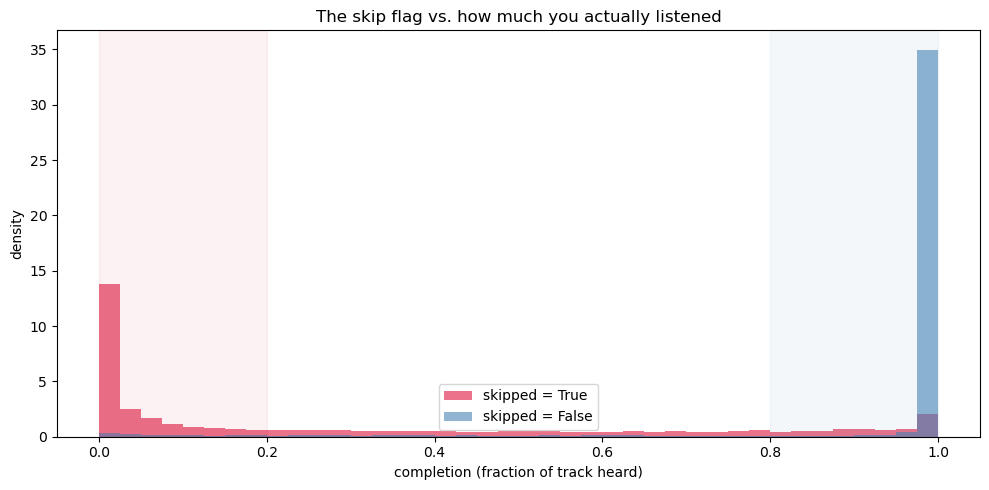

'skipped=True' plays that were actually >=80% heard : 1,148 of 7,406  (15.5%)  <- flag says hate, you finished it
'skipped=False' plays you bailed on <=20%           : 309 of 9,420  (3.3%)  <- real dislike the flag missed


In [46]:
skipped_bool = plays['skipped'].fillna(False).astype(bool)

fig, ax = plt.subplots(figsize=(10, 5))
bins = np.linspace(0, 1, 41)
ax.hist(plays.loc[skipped_bool, 'completion'],  bins=bins, alpha=0.6,
        label='skipped = True',  color='crimson', density=True)
ax.hist(plays.loc[~skipped_bool, 'completion'], bins=bins, alpha=0.6,
        label='skipped = False', color='steelblue', density=True)
ax.axvspan(0.0, 0.2, color='crimson',    alpha=0.06)
ax.axvspan(0.8, 1.0, color='steelblue',  alpha=0.06)
ax.set_xlabel('completion (fraction of track heard)')
ax.set_ylabel('density')
ax.set_title('The skip flag vs. how much you actually listened')
ax.legend()
plt.tight_layout()
plt.show()

n_skip = int(skipped_bool.sum())
last_second = int((skipped_bool & (plays['completion'] >= 0.8)).sum())
silent_abandon = int((~skipped_bool & (plays['completion'] <= 0.2)).sum())
print(f"'skipped=True' plays that were actually >=80% heard : "
      f"{last_second:,} of {n_skip:,}  ({last_second/n_skip:.1%})  <- flag says hate, you finished it")
print(f"'skipped=False' plays you bailed on <=20%           : "
      f"{silent_abandon:,} of {(~skipped_bool).sum():,}  ({silent_abandon/(~skipped_bool).sum():.1%})  <- real dislike the flag missed")

### Experiment 1 — The anatomy of a completion score

The raw shape of `completion` matters because it decides how we should aggregate. We split every play into three zones and measure how big each is:

- **Abandoned** (< 0.3) — bailed early, the clearest dislike signal.
- **Partial** (0.3 – 0.8) — background / half-listened.
- **Finished** (> 0.8) — rode it out.


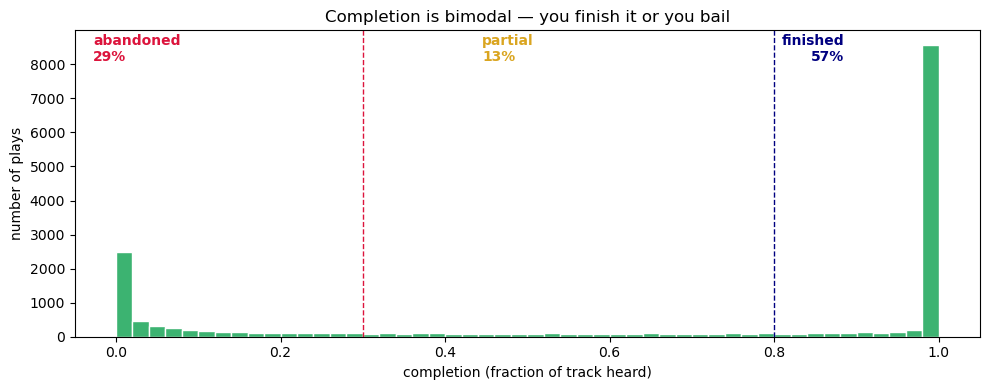

abandoned (<0.3): 29.4%   partial: 13.3%   finished (>0.8): 57.3%


In [9]:
ABANDON = 0.3   # below this = "abandoned early" = the hate event
FINISH  = 0.8   # above this = "rode it out"

abandoned = (plays['completion'] < ABANDON).mean()
partial   = ((plays['completion'] >= ABANDON) & (plays['completion'] <= FINISH)).mean()
finished  = (plays['completion'] > FINISH).mean()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(plays['completion'], bins=50, color='mediumseagreen', edgecolor='white')
ax.axvline(ABANDON, color='crimson', ls='--', lw=1)
ax.axvline(FINISH,  color='navy',    ls='--', lw=1)
ax.set_xlabel('completion (fraction of track heard)')
ax.set_ylabel('number of plays')
ax.set_title('Completion is bimodal — you finish it or you bail')
ax.text(0.02, 0.9, f'abandoned\n{abandoned:.0%}', transform=ax.transAxes, color='crimson', fontweight='bold')
ax.text(0.45, 0.9, f'partial\n{partial:.0%}',      transform=ax.transAxes, color='goldenrod', fontweight='bold')
ax.text(0.85, 0.9, f'finished\n{finished:.0%}',    transform=ax.transAxes, color='navy', fontweight='bold', ha='right')
plt.tight_layout()
plt.show()

print(f"abandoned (<{ABANDON}): {abandoned:.1%}   partial: {partial:.1%}   finished (>{FINISH}): {finished:.1%}")

### Method A — Lowest mean completion (the simple one)

Group by track/artist, average the completion, keep only entities with enough plays, and the **lowest average = most hated**. Dead simple, no thresholds, easy to explain on a dashboard card ("you only ever get 12% into this one").

The catch: a hard `min_plays` cutoff is arbitrary, and one track played twice at 5% can still edge out a track played 40 times at 15%. Methods B and C fix that.


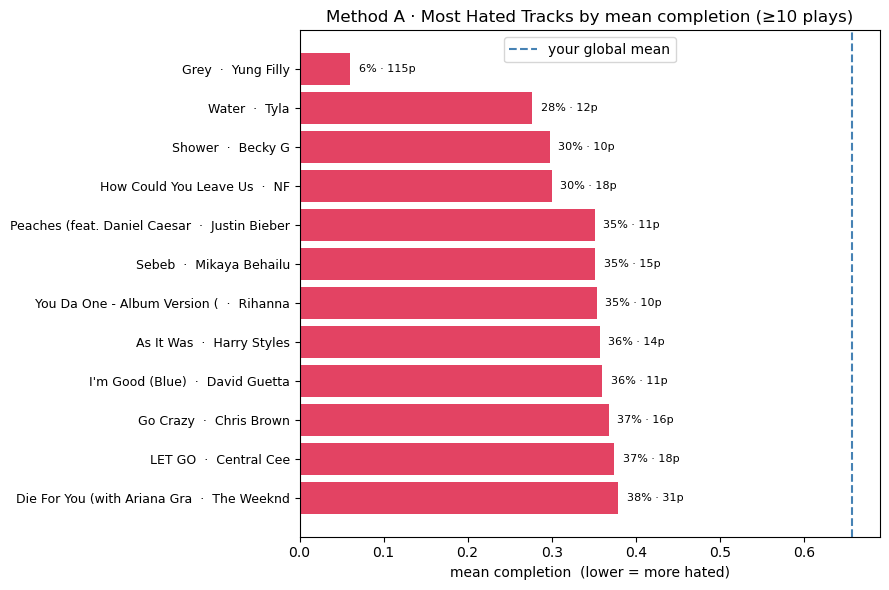

In [10]:
def hate_stats(level='track', min_plays=10):
    """Aggregate the completion signal per track or artist."""
    key = 'track_name' if level == 'track' else 'artist_name'
    g = plays.groupby(key).agg(
        plays=('completion', 'size'),
        mean_completion=('completion', 'mean'),
        abandon_rate=('completion', lambda s: (s < ABANDON).mean()),
        abandons=('completion', lambda s: int((s < ABANDON).sum())),
        artist=('artist_name', 'first'),
    )
    return g[g['plays'] >= min_plays].copy()

track_hate = hate_stats('track', min_plays=10)

topA = track_hate.nsmallest(12, 'mean_completion').iloc[::-1]
labels = [f"{name[:28]}  ·  {row.artist[:18]}" for name, row in topA.iterrows()]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(range(len(topA)), topA['mean_completion'], color='crimson', alpha=0.8)
ax.axvline(plays['completion'].mean(), color='steelblue', ls='--', label='your global mean')
ax.set_yticks(range(len(topA)))
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel('mean completion  (lower = more hated)')
ax.set_title('Method A · Most Hated Tracks by mean completion (≥10 plays)')
for i, (_, row) in enumerate(topA.iterrows()):
    ax.text(row['mean_completion'] + 0.01, i, f"{row['mean_completion']:.0%} · {int(row['plays'])}p", va='center', fontsize=8)
ax.legend()
plt.tight_layout()
plt.show()

### Method B — Abandonment rate + Wilson lower bound (the rigorous one)

This is your §18–19 methodology, but the "hate event" is now **"abandoned before 30%"** instead of the unreliable skip flag. For each track we ask: *what fraction of plays did you bail early?* — then rank by the **Wilson 95% lower bound** of that rate, not the raw rate.

Why the lower bound: it automatically discounts small samples (a 2-play track has a wide interval, so its lower bound sinks), so a track only earns "most hated" when there's **strong evidence** you consistently bail. This is the most defensible number to put on a public/leaderboard card.


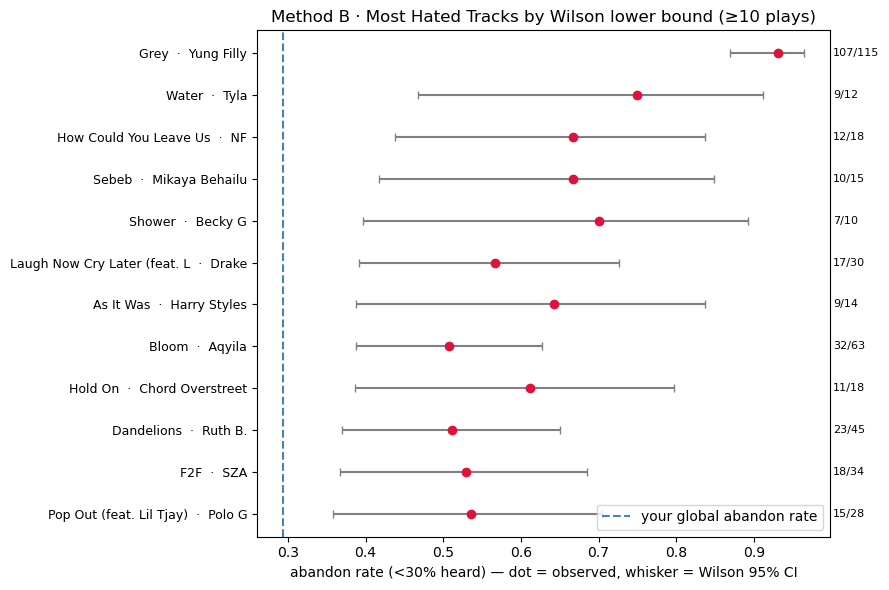

In [11]:
from statsmodels.stats.proportion import proportion_confint

def add_wilson(stats):
    lo, hi = proportion_confint(stats['abandons'], stats['plays'], alpha=0.05, method='wilson')
    stats = stats.assign(wilson_low=lo, wilson_high=hi)
    return stats

track_hate = add_wilson(track_hate)
global_abandon = (plays['completion'] < ABANDON).mean()

topB = track_hate.nlargest(12, 'wilson_low').sort_values('wilson_low')
labels = [f"{name[:28]}  ·  {row.artist[:18]}" for name, row in topB.iterrows()]
y = range(len(topB))
xerr_low  = np.clip(topB['abandon_rate'] - topB['wilson_low'],  0, None)
xerr_high = np.clip(topB['wilson_high']  - topB['abandon_rate'], 0, None)

fig, ax = plt.subplots(figsize=(9, 6))
ax.errorbar(topB['abandon_rate'], y, xerr=[xerr_low, xerr_high],
            fmt='o', color='crimson', ecolor='gray', capsize=3)
ax.axvline(global_abandon, color='steelblue', ls='--', label='your global abandon rate')
ax.set_yticks(list(y))
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel('abandon rate (<30% heard) — dot = observed, whisker = Wilson 95% CI')
ax.set_title('Method B · Most Hated Tracks by Wilson lower bound (≥10 plays)')
for i, (_, row) in enumerate(topB.iterrows()):
    ax.text(1.005, i, f"{int(row['abandons'])}/{int(row['plays'])}", transform=ax.get_yaxis_transform(), va='center', fontsize=8)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Method C — Bayesian shrinkage (the no-threshold one)

Both A and B need a `min_plays` cutoff, which throws away every track you played 3–4 times. Shrinkage keeps them all but refuses to trust them blindly. We pull each track's mean completion toward your global mean by a prior worth `C` "phantom average plays":

$$\text{score} = \frac{C \cdot m_{\text{global}} + \sum \text{completion}}{C + n}$$

A track with 100 low plays barely moves (strong evidence → stays hated); a track with 2 low plays gets yanked back toward average (weak evidence → not trusted yet). No hard cutoff, every track ranked on one smooth scale — the same trick IMDb uses for its Top 250.


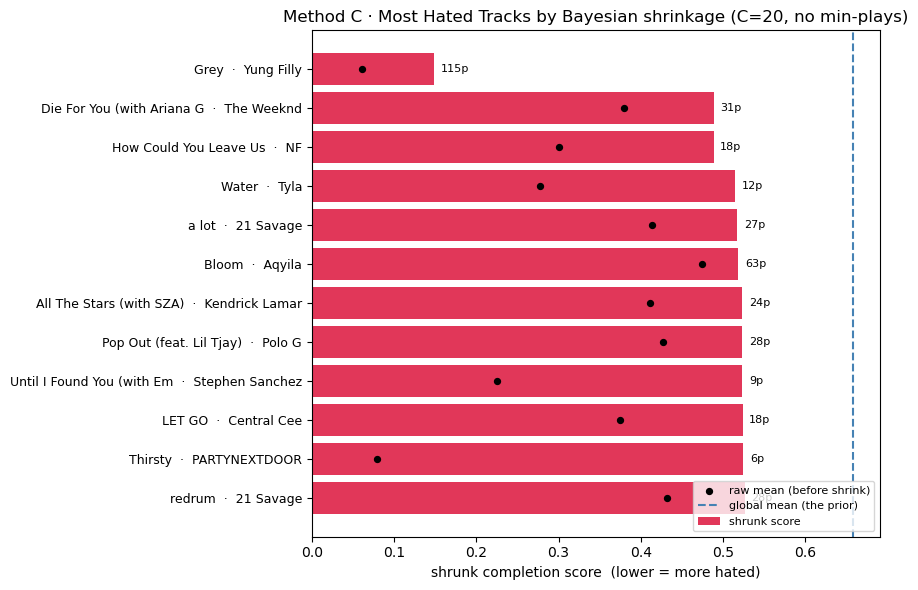

In [12]:
C = 20                                 # prior strength = 8 "phantom average plays"
m_global = plays['completion'].mean()

# aggregate ALL tracks (no min_plays filter — shrinkage self-regulates)
all_tracks = plays.groupby('track_name').agg(
    plays=('completion', 'size'),
    mean_completion=('completion', 'mean'),
    artist=('artist_name', 'first'),
)
all_tracks['shrunk'] = (C * m_global + all_tracks['plays'] * all_tracks['mean_completion']) / (C + all_tracks['plays'])

topC = all_tracks.nsmallest(12, 'shrunk').iloc[::-1]
labels = [f"{name[:26]}  ·  {row.artist[:16]}" for name, row in topC.iterrows()]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(range(len(topC)), topC['shrunk'], color='crimson', alpha=0.85, label='shrunk score')
ax.scatter(topC['mean_completion'], range(len(topC)), color='black', s=18, zorder=3, label='raw mean (before shrink)')
ax.axvline(m_global, color='steelblue', ls='--', label='global mean (the prior)')
ax.set_yticks(range(len(topC)))
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel('shrunk completion score  (lower = more hated)')
ax.set_title(f'Method C · Most Hated Tracks by Bayesian shrinkage (C={C}, no min-plays)')
for i, (_, row) in enumerate(topC.iterrows()):
    ax.text(row['shrunk'] + 0.008, i, f"{int(row['plays'])}p", va='center', fontsize=8)
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

### Method D — Full Bayes: fitted prior + credible interval

Method C was Bayesian-*lite*: the formula $\frac{C\,m + \sum x_i}{C + n}$ is exactly the **posterior mean of a Beta prior**, but I hand-picked the prior strength `C` and only kept the point estimate. Method D does the whole thing properly:

1. **Binarize the event** — "abandoned before 30%" is a real coin-flip (Bernoulli), so the Beta–Binomial model is *exact* instead of a heuristic on fractional completions.
2. **Fit the prior from your data** (Empirical Bayes, method of moments) — the prior strength $\kappa$ is *learned* from how spread out your per-track abandon rates are, not guessed. Cluster tightly → strong prior (shrink hard); all over the place → weak prior (trust the data).
3. **Keep the whole posterior**, not just its mean. Each track gets a full $\text{Beta}(\alpha_0+k,\ \beta_0+n-k)$ distribution, which gives:
   - a **95% credible interval** (the Bayesian twin of Method B's Wilson interval — rank by its lower bound for the conservative "most robustly hated"),
   - and **`p_worse`** = the probability your true abandon rate for this track beats your global rate — a plain-English number like *"96% sure you bail on this more than average"* that reads perfectly on a card.

Prior mean $\mu_0$ and strength $\kappa$ via method of moments on the observed rates $\hat p_i = k_i/n_i$:

$$\kappa = \frac{\mu_0(1-\mu_0)}{s^2} - 1, \qquad \alpha_0 = \kappa\mu_0, \qquad \beta_0 = \kappa(1-\mu_0)$$


fitted prior: Beta(1.41, 3.52)  ->  mean=0.286, strength(kappa)=4.9
(Method C hand-tuned C=20; the data itself suggests 4.9)


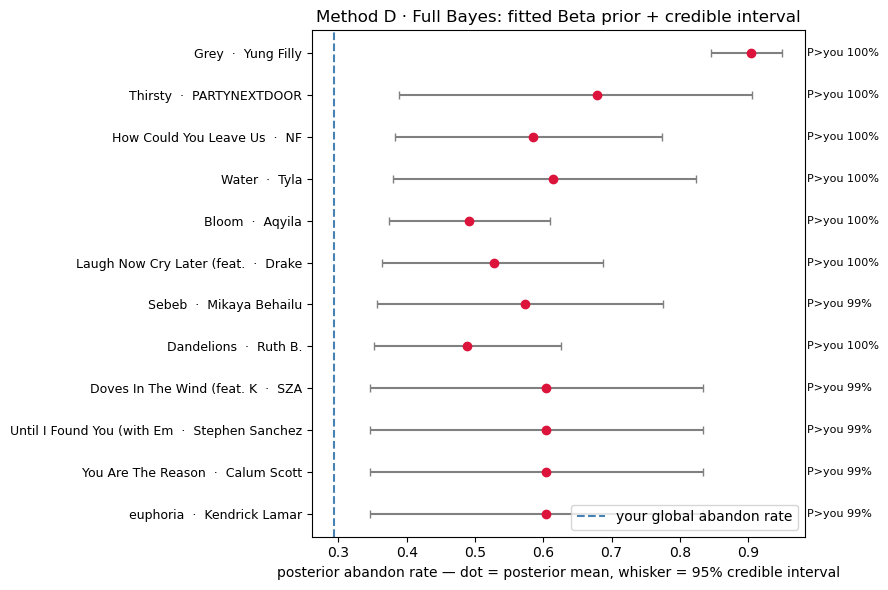

,artist,n,k,post_mean,cred_low,cred_high,p_worse
track_name,,,,,,,
Grey,Yung Filly,115,107.0,0.904,0.845,0.950,1.000
Thirsty,PARTYNEXTDOOR,6,6.0,0.678,0.389,0.906,0.996
How Could You Leave Us,NF,18,12.0,0.585,0.382,0.773,0.998
Water,Tyla,12,9.0,0.615,0.380,0.824,0.997
Bloom,Aqyila,63,32.0,0.492,0.374,0.610,1.000
Laugh Now Cry Later (feat. Lil Durk),Drake,30,17.0,0.527,0.363,0.688,0.998
Sebeb,Mikaya Behailu,15,10.0,0.573,0.356,0.775,0.995
Dandelions,Ruth B.,45,23.0,0.489,0.353,0.626,0.998
Doves In The Wind (feat. Kendrick Lamar),SZA,9,7.0,0.604,0.346,0.833,0.992


In [13]:
from scipy.stats import beta as beta_dist

# event = "abandoned before 30%" -> a real Bernoulli, so Beta-Binomial is exact
et = plays.groupby('track_name').agg(
    n=('completion', 'size'),
    k=('completion', lambda s: int((s < ABANDON).sum())),
    artist=('artist_name', 'first'),
)

# --- 1. FIT the prior from your data (method of moments) instead of guessing C ---
seen = et[et['n'] >= 5]                     # tracks with enough plays to gauge the spread
p = seen['k'] / seen['n']
mu, var = p.mean(), p.var(ddof=1)
kappa = max(mu * (1 - mu) / var - 1, 0.5)   # prior strength, learned (guarded > 0)
alpha0, beta0 = kappa * mu, kappa * (1 - mu)
print(f"fitted prior: Beta({alpha0:.2f}, {beta0:.2f})  ->  mean={mu:.3f}, strength(kappa)={kappa:.1f}")
print(f"(Method C hand-tuned C=20; the data itself suggests {kappa:.1f})")

# --- 2. Full posterior per track ---
a_post = alpha0 + et['k']
b_post = beta0 + et['n'] - et['k']
et['post_mean'] = a_post / (a_post + b_post)                       # Bayes point estimate
et['cred_low']  = beta_dist.ppf(0.025, a_post, b_post)            # 95% credible interval
et['cred_high'] = beta_dist.ppf(0.975, a_post, b_post)
et['p_worse']   = 1 - beta_dist.cdf(global_abandon, a_post, b_post)  # P(you hate it > average)

# --- 3. Rank by the credible-interval lower bound (conservative "most robustly hated") ---
topD = et.nlargest(12, 'cred_low').sort_values('cred_low')
labels = [f"{name[:26]}  ·  {row.artist[:16]}" for name, row in topD.iterrows()]
y = range(len(topD))
xerr_low  = np.clip(topD['post_mean'] - topD['cred_low'],  0, None)
xerr_high = np.clip(topD['cred_high'] - topD['post_mean'], 0, None)

fig, ax = plt.subplots(figsize=(9, 6))
ax.errorbar(topD['post_mean'], y, xerr=[xerr_low, xerr_high],
            fmt='o', color='crimson', ecolor='gray', capsize=3)
ax.axvline(global_abandon, color='steelblue', ls='--', label='your global abandon rate')
ax.set_yticks(list(y))
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel('posterior abandon rate — dot = posterior mean, whisker = 95% credible interval')
ax.set_title('Method D · Full Bayes: fitted Beta prior + credible interval')
for i, (_, row) in enumerate(topD.iterrows()):
    ax.text(1.005, i, f"P>you {row['p_worse']:.0%}", transform=ax.get_yaxis_transform(), va='center', fontsize=8)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

et.nlargest(10, 'cred_low')[['artist', 'n', 'k', 'post_mean', 'cred_low', 'cred_high', 'p_worse']].round(3)

### Side-by-side — who does each method crown?

The three methods mostly agree at the top (a good sign the signal is real) but diverge in the mid-pack where sample size matters. Here's the top 10 from each, aligned rank-for-rank.


In [14]:
def label(idx, stats):
    return [f"{n[:24]} · {stats.loc[n, 'artist'][:14]}" for n in idx]

a = track_hate.nsmallest(10, 'mean_completion').index
b = track_hate.nlargest(10, 'wilson_low').index
c = all_tracks.nsmallest(10, 'shrunk').index
d = et.nlargest(10, 'cred_low').index

comparison = pd.DataFrame({
    'A · mean completion':  label(a, track_hate),
    'B · Wilson lower':     label(b, track_hate),
    'C · shrinkage':        label(c, all_tracks),
    'D · full Bayes':       label(d, et),
}, index=range(1, 11))
comparison.index.name = 'rank'
comparison

,A · mean completion,B · Wilson lower,C · shrinkage,D · full Bayes
rank,,,,
1,Grey · Yung Filly,Grey · Yung Filly,Grey · Yung Filly,Grey · Yung Filly
2,Water · Tyla,Water · Tyla,Die For You (with Ariana · The Weeknd,Thirsty · PARTYNEXTDOOR
3,Shower · Becky G,How Could You Leave Us · NF,How Could You Leave Us · NF,How Could You Leave Us · NF
4,How Could You Leave Us · NF,Sebeb · Mikaya Behailu,Water · Tyla,Water · Tyla
5,Peaches (feat. Daniel Ca · Justin Bieber,Shower · Becky G,a lot · 21 Savage,Bloom · Aqyila
6,Sebeb · Mikaya Behailu,Laugh Now Cry Later (fea · Drake,Bloom · Aqyila,Laugh Now Cry Later (fea · Drake
7,You Da One - Album Versi · Rihanna,As It Was · Harry Styles,All The Stars (with SZA) · Kendrick Lamar,Sebeb · Mikaya Behailu
8,As It Was · Harry Styles,Bloom · Aqyila,Pop Out (feat. Lil Tjay) · Polo G,Dandelions · Ruth B.
9,I'm Good (Blue) · David Guetta,Hold On · Chord Overstre,Until I Found You (with · Stephen Sanche,Doves In The Wind (feat. · SZA


### Most Hated Artist — same three methods

Rolling the completion signal up to the artist level (≥ 30 plays so we're judging artists you actually gave a chance). The chart uses Method B (Wilson lower bound); the table shows all three side by side.


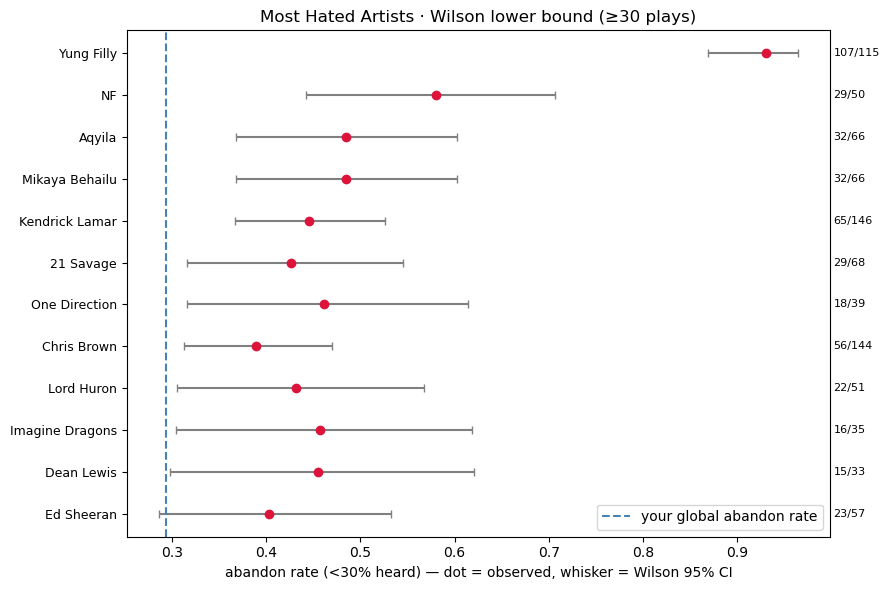

,A · mean completion,B · Wilson lower,C · shrinkage
rank,,,
1,Yung Filly,Yung Filly,Yung Filly
2,NF,NF,Eyob Mekonen
3,Mikaya Behailu,Aqyila,Mulatu Astatke
4,21 Savage,Mikaya Behailu,Abraham Gebremedhin
5,Iniko,Kendrick Lamar,Theodros Tadesse
6,Aqyila,21 Savage,Neway Debebe
7,Kendrick Lamar,One Direction,Nhatty Man
8,Imagine Dragons,Chris Brown,Gossaye Tesfaye


In [52]:
artist_hate = add_wilson(hate_stats('artist', min_plays=30))

# shrinkage over ALL artists (no min-plays) for column C
all_artists = plays.groupby('artist_name').agg(
    plays=('completion', 'size'),
    mean_completion=('completion', 'mean'),
)
all_artists['shrunk'] = (C * m_global + all_artists['plays'] * all_artists['mean_completion']) / (C + all_artists['plays'])

topB_art = artist_hate.nlargest(12, 'wilson_low').sort_values('wilson_low')
y = range(len(topB_art))
xerr_low  = np.clip(topB_art['abandon_rate'] - topB_art['wilson_low'],  0, None)
xerr_high = np.clip(topB_art['wilson_high']  - topB_art['abandon_rate'], 0, None)

fig, ax = plt.subplots(figsize=(9, 6))
ax.errorbar(topB_art['abandon_rate'], y, xerr=[xerr_low, xerr_high],
            fmt='o', color='crimson', ecolor='gray', capsize=3)
ax.axvline(global_abandon, color='steelblue', ls='--', label='your global abandon rate')
ax.set_yticks(list(y))
ax.set_yticklabels(topB_art.index, fontsize=9)
ax.set_xlabel('abandon rate (<30% heard) — dot = observed, whisker = Wilson 95% CI')
ax.set_title('Most Hated Artists · Wilson lower bound (≥30 plays)')
for i, (_, row) in enumerate(topB_art.iterrows()):
    ax.text(1.005, i, f"{int(row['abandons'])}/{int(row['plays'])}", transform=ax.get_yaxis_transform(), va='center', fontsize=8)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

art_cmp = pd.DataFrame({
    'A · mean completion': artist_hate.nsmallest(8, 'mean_completion').index,
    'B · Wilson lower':    artist_hate.nlargest(8, 'wilson_low').index,
    'C · shrinkage':       all_artists.nsmallest(8, 'shrunk').index,
}, index=range(1, 9))
art_cmp.index.name = 'rank'
art_cmp

### Verdict — which one to ship

**The signal is settled:** completion beats the skip flag (Exp 0 proved the flag mislabels ~1 in 6 skips and misses silent dislike). Whatever we pick, it's built on `ms_played / duration`, not `skipped`.

**The ranking method is your call — the tradeoffs:**

| Method | Strength | Weakness | Best for |
|---|---|---|---|
| **A · mean completion** | dead simple, great card copy ("you only get 6% in") | arbitrary `min_plays` cutoff; tiny-n noise | the friendly dashboard subtitle |
| **B · Wilson lower bound** | most defensible; auto-penalizes small samples; reuses your §18–19 code | needs the `abandon<0.3` threshold; "lower bound" is less intuitive | the backend metric / any leaderboard |
| **C · Bayesian shrinkage** | one smooth scale, no cutoff at all | prior `C` is hand-picked; too weak for the artist tail → leaked obscure 1–2-play artists | when you refuse to drop low-play items |
| **D · full Bayes (fitted prior)** | prior strength *learned* from your data (κ≈4.9, not guessed); gives a credible interval **and** a `p_worse` probability ("100% sure you bail more than average") | most code; the method-of-moments prior needs a guard against over-dispersion | the backend metric **and** a great card story |

**My recommendation:** **Method D** is now the best of all worlds — it's Method C done honestly (no hand-picked `C`) *and* Method B's rigor (a credible interval you can rank by its lower bound), plus the bonus `p_worse` line that reads perfectly on a card. Ship **Method D**, rank by `cred_low`, and surface `p_worse` + raw mean completion as the human-readable subtitle. If you'd rather keep it lean, **Method B** is the close runner-up and reuses your existing §18–19 code.

All four methods agree your most hated track is **"Grey" by Yung Filly** (107/115 plays abandoned, `p_worse`=100%) and most hated artist is **Yung Filly** — the top of the board is rock-solid regardless of which you pick. Tell me which one and I'll wire it into `backend/main.py` as `/api/metrics/most-hated`.